In [2]:
import os
import glob
import numpy as np
import xarray as xr
import nc_time_axis
from importlib import reload
import xesmf as xe

import matplotlib as mpl
import matplotlib.pyplot as plt
from cartopy import crs as ccrs, feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy

import funcs_grid as gf

In [3]:
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import pandas as pd
import requests
import xarray as xr

import earthaccess

CMR_COLLECTIONS = "https://cmr.earthdata.nasa.gov/search/collections.json"
CMR_GRANULES = "https://cmr.earthdata.nasa.gov/search/granules.json"

chunks = {'time':-1}

def preprocessor(ds):
    return ds.rename({'latitude':'lat','longitude':'lon'})

In [4]:
auth = earthaccess.login()
auth

# ECCOv4

In [5]:
short_name = "ECCO_L4_TEMP_SALINITY_05DEG_DAILY_V4R4"
temp_ecco4_results = earthaccess.search_data(
    short_name=short_name,
    cloud_hosted=True,
    temporal=("2017-01-01", "2017-01-31"),
)

opened = earthaccess.open(temp_ecco4_results)

temp_ecco4_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
                                 combine='by_coords',coords='minimal',
                                  preprocess=preprocessor,parallel=True)
temp_ecco4_ds

QUEUEING TASKS | :   0%|          | 0/32 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/32 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/32 [00:00<?, ?it/s]

/tmp/ipykernel_84/426970175.py:10: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  temp_ecco4_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
/tmp/ipykernel_84/426970175.py:10: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  temp_ecco4_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
/tmp/ipykernel_84/4269

<xarray.Dataset> Size: 3GB
Dimensions:         (time: 32, Z: 50, lat: 360, lon: 720, nv: 2)
Coordinates:
  * time            (time) datetime64[ns] 256B 2016-12-31T12:00:00 ... 2017-0...
  * Z               (Z) float32 200B -5.0 -15.0 -25.0 ... -5.461e+03 -5.906e+03
  * lat             (lat) float32 1kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * lon             (lon) float32 3kB -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
    time_bnds       (time, nv) datetime64[ns] 512B dask.array<chunksize=(1, 2), meta=np.ndarray>
    latitude_bnds   (lat, nv) float32 3kB dask.array<chunksize=(360, 2), meta=np.ndarray>
    longitude_bnds  (lon, nv) float32 6kB dask.array<chunksize=(720, 2), meta=np.ndarray>
    Z_bnds          (Z, nv) float32 400B dask.array<chunksize=(50, 2), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables:
    THETA           (time, Z, lat, lon) float32 2GB dask.array<chunksize=(1, 25, 180, 360), meta=np.ndarray>
    SALT            (time, Z, lat, lon) float32 2GB dask.array<chunksize=(1, 25, 180, 360), meta=np.ndarray>
Attributes: (12/62)
    acknowledgement:                 This research was carried out by the Jet...
    author:                          Ian Fenty and Ou Wang
    cdm_data_type:                   Grid
    comment:                         Fields provided on a regular lat-lon gri...
    Conventions:                     CF-1.8, ACDD-1.3
    coordinates_comment:             Note: the global 'coordinates' attribute...
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_end:               2017-01-01T00:00:00
    time_coverage_resolution:        P1D
    time_coverage_start:             2016-12-31T00:00:00
    title:                           ECCO Ocean Temperature and Salinity - Da...
    uuid:                            1581c426-4128-11eb-8800-0cc47a3f575f

In [6]:
short_name = "ECCO_L4_SSH_05DEG_DAILY_V4R4"
ssh_ecco4_results = earthaccess.search_data(
    short_name=short_name,
    cloud_hosted=True,
    temporal=("2017-01-01", "2017-01-31"),
)

opened = earthaccess.open(ssh_ecco4_results)

ssh_ecco4_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
                                 combine='by_coords',coords='minimal',
                                  preprocess=preprocessor,parallel=True)
ssh_ecco4_ds

QUEUEING TASKS | :   0%|          | 0/32 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/32 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/32 [00:00<?, ?it/s]

/tmp/ipykernel_84/1359530202.py:10: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ssh_ecco4_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
/tmp/ipykernel_84/1359530202.py:10: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ssh_ecco4_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',


<xarray.Dataset> Size: 100MB
Dimensions:         (time: 32, lat: 360, lon: 720, nv: 2)
Coordinates:
  * time            (time) datetime64[ns] 256B 2016-12-31T12:00:00 ... 2017-0...
  * lat             (lat) float32 1kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * lon             (lon) float32 3kB -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
    time_bnds       (time, nv) datetime64[ns] 512B dask.array<chunksize=(1, 2), meta=np.ndarray>
    latitude_bnds   (lat, nv) float32 3kB dask.array<chunksize=(360, 2), meta=np.ndarray>
    longitude_bnds  (lon, nv) float32 6kB dask.array<chunksize=(720, 2), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables:
    SSH             (time, lat, lon) float32 33MB dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
    SSHIBC          (time, lat, lon) float32 33MB dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
    SSHNOIBC        (time, lat, lon) float32 33MB dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
Attributes: (12/57)
    acknowledgement:              This research was carried out by the Jet Pr...
    author:                       Ian Fenty and Ou Wang
    cdm_data_type:                Grid
    comment:                      Fields provided on a regular lat-lon grid. ...
    Conventions:                  CF-1.8, ACDD-1.3
    coordinates_comment:          Note: the global 'coordinates' attribute de...
    ...                           ...
    time_coverage_duration:       P1D
    time_coverage_end:            2017-01-01T00:00:00
    time_coverage_resolution:     P1D
    time_coverage_start:          2016-12-31T00:00:00
    title:                        ECCO Sea Surface Height - Daily Mean 0.5 De...
    uuid:                         18899d08-404a-11eb-82ab-0cc47a3f891b

In [92]:
reload(gf)
dx_ecco4_5deg,dy_ecco4_5deg = gf.cdtdim_xr(ssh_ecco4_ds.lat,ssh_ecco4_ds.lon)
coriolis = gf.calc_coriolis(ssh_ecco4_ds.lat)
g = 9.81

vgos_ecco4_5deg = (g/coriolis)*gf.xr_first_derivative(ssh_ecco4_ds.SSH,dx_ecco4_5deg,dim='lon')
vgos_ecco4_5deg = vgos_ecco4_5deg.where(abs(vgos_ecco4_5deg.lat) > 2)

In [8]:
sst_ecco4_ds = temp_ecco4_ds.THETA.isel(Z=0,drop=True)
sst_ecco4_ds

<xarray.DataArray 'THETA' (time: 32, lat: 360, lon: 720)> Size: 33MB
dask.array<getitem, shape=(32, 360, 720), dtype=float32, chunksize=(1, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 256B 2016-12-31T12:00:00 ... 2017-01-31T12...
  * lat      (lat) float32 1kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float32 3kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes:
    coverage_content_type:  modelResult
    long_name:              Potential temperature 
    standard_name:          sea_water_potential_temperature
    units:                  degree_C
    comment:                Sea water potential temperature is the temperatur...
    valid_min:              -2.9179372787475586
    valid_max:              36.425140380859375

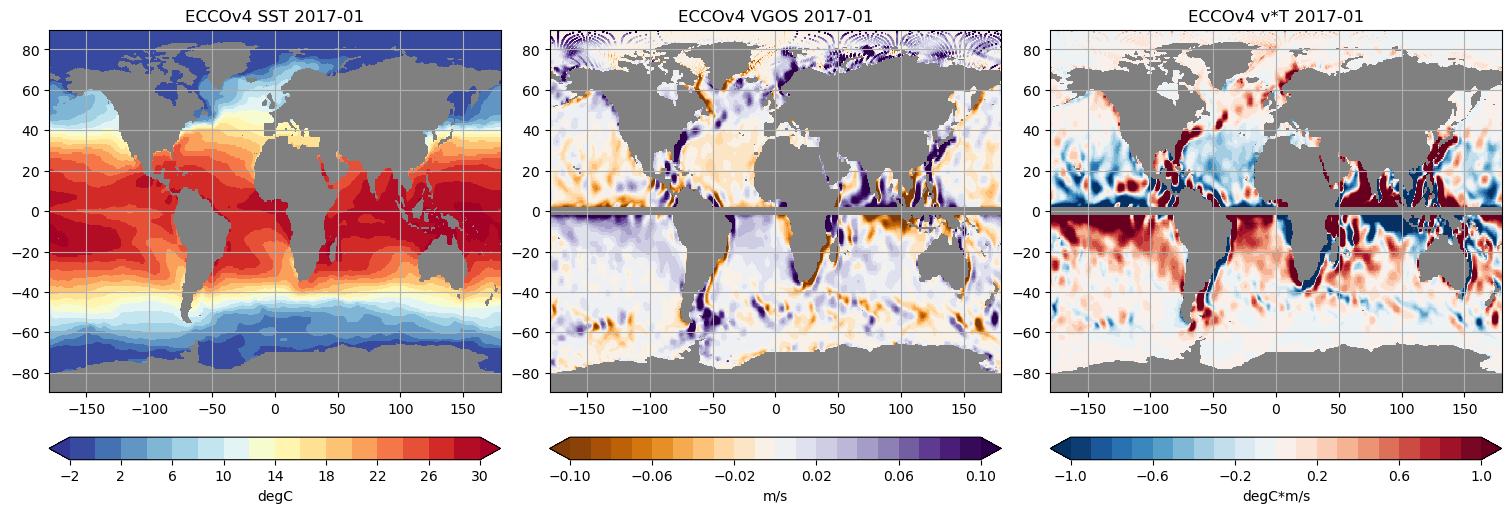

In [94]:
fig,axs = plt.subplots(1,3,figsize=(15,5),layout='constrained')

ax = axs[0] ; ax.set_title('ECCOv4 SST 2017-01')
dat = sst_ecco4_ds.mean('time')
cmap = 'RdYlBu_r' ; levels = np.arange(-2,31,2)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::2],orientation='horizontal',label='degC')

ax = axs[1] ; ax.set_title('ECCOv4 VGOS 2017-01')
dat = vgos_ecco4_5deg.mean('time')
cmap = 'PuOr' ; levels = np.linspace(-0.1,0.1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='m/s')

ax = axs[2] ; ax.set_title('ECCOv4 v*T 2017-01')
dat = (sst_ecco4_ds*vgos_ecco4_5deg).mean('time')
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

for ax in axs:
    ax.grid()
    ax.set_facecolor('gray')
    

# Observations

In [9]:
auth = earthaccess.login()

In [ ]:
short_name = "MUR25-JPL-L4-GLOB-v04.2"
sst_mur25_results = earthaccess.search_data(
    short_name=short_name,
    cloud_hosted=True,
    temporal=("2017-01-01", "2017-01-31"),
)

opened = earthaccess.open(sst_mur25_results)

sst_mur25_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
                                 combine='by_coords',coords='minimal',parallel=True) - 273.15
sst_mur25_ds['time'] = sst_mur25_ds.time.astype('datetime64[D]').astype('datetime64[ns]') 

In [32]:
short_name = "NEUROST_SSH-SST_L4_V2024.0"
ssh_neuro_results = earthaccess.search_data(
    short_name=short_name,
    cloud_hosted=True,
    temporal=("2017-01-01", "2017-01-31"),
)

opened = earthaccess.open(ssh_neuro_results)
ssh_neuro_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
                                 combine='by_coords',coords='minimal',
                                 preprocess=preprocessor,parallel=True)
ssh_neuro_ds

QUEUEING TASKS | :   0%|          | 0/32 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/32 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/32 [00:00<?, ?it/s]

/tmp/ipykernel_84/3619966587.py:9: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ssh_neuro_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',


<xarray.Dataset> Size: 6GB
Dimensions:                 (lat: 1500, lon: 3600, time: 32)
Coordinates:
  * lat                     (lat) float64 12kB -70.0 -69.9 -69.8 ... 79.8 79.9
  * lon                     (lon) float64 29kB 0.1 0.2 0.3 ... 359.8 359.9 360.0
  * time                    (time) datetime64[ns] 256B 2016-12-31 ... 2017-01-31
    Lambert_Azimuthal_Grid  int32 4B -2147483647
Data variables:
    sla                     (lat, lon, time) float32 691MB dask.array<chunksize=(1500, 3600, 1), meta=np.ndarray>
    adt                     (lat, lon, time) float32 691MB dask.array<chunksize=(1500, 3600, 1), meta=np.ndarray>
    ugosa                   (lat, lon, time) float32 691MB dask.array<chunksize=(1500, 3600, 1), meta=np.ndarray>
    vgosa                   (lat, lon, time) float32 691MB dask.array<chunksize=(1500, 3600, 1), meta=np.ndarray>
    sn                      (lat, lon, time) float32 691MB dask.array<chunksize=(1500, 3600, 1), meta=np.ndarray>
    ss                      (lat, lon, time) float32 691MB dask.array<chunksize=(1500, 3600, 1), meta=np.ndarray>
    zeta                    (lat, lon, time) float32 691MB dask.array<chunksize=(1500, 3600, 1), meta=np.ndarray>
    ugos                    (lat, lon, time) float32 691MB dask.array<chunksize=(1500, 3600, 1), meta=np.ndarray>
    vgos                    (lat, lon, time) float32 691MB dask.array<chunksize=(1500, 3600, 1), meta=np.ndarray>
Attributes: (12/37)
    title:                      Daily NeurOST (SSH-SST) Sea Surface Height an...
    summary:                    A mapped level 4 sea surface height analysis ...
    Conventions:                CF-1.10
    standard_name_vocabulary:   NetCDF Climate and Forecast (CF) Metadata Con...
    keywords:                   Oceans > Sea Surface Topography > Sea Surface...
    keywords_vocabulary:        NASA Global Change Master Directory (GCMD) Sc...
    ...                         ...
    creator_url:                http://podaac.jpl.nasa.gov
    publisher_name:             JPL PO.DAAC
    publisher_url:              http://podaac.jpl.nasa.gov
    date_created:               2024-05-06T15:26:05.166790
    references:                 https://doi.org/10.31223/X5W676 and https://d...
    comment:                    NeurOST = Neural Ocean Surface Topography. Ne...

In [12]:
# regrid with xesmf
"""
For now, use bilinear regridding from xesmf. In principle, conservative remapping should be used
to retain flux closures, but since this is an interpolated observational data product, we cannot
actual close any budgets. For visualization, this will do. 
"""

'\nFor now, use bilinear regridding from xesmf. In principle, conservative remapping should be used\nto retain flux closures, but since this is an interpolated observational data product, we cannot\nactual close any budgets. For visualization, this will do. \n'

In [26]:
# sst_mur25 remap
outdir = '~/tamu/ocng-689/ocng-489-689-2026-spring/tprochko/grids/'
fout = 'sst_mur25_to_ecco4_5deg_bilinear_remap.nc'
ds_in = sst_mur25_ds.analysed_sst.isel(time=0,drop=True).rename({'lat':'y','lon':'x'})
ds_out = xr.Dataset(
    {
        "lat": (["lat"], ssh_ecco4_ds.lat.data, {"units": "degrees_north"}),
        "lon": (["lon"], ssh_ecco4_ds.lon.data, {"units": "degrees_east"}),
    }
)

In [27]:
%%time
regridder = xe.Regridder(ds_in, ds_out, 'bilinear')
# tried periodic=True, but it kept blowing up. 
fn = regridder.to_netcdf(os.path.join(outdir,fout))
regridder

CPU times: user 16.6 s, sys: 375 ms, total: 17 s
Wall time: 17.2 s


xESMF Regridder 
Regridding algorithm:       bilinear 
Weight filename:            bilinear_720x1440_360x720.nc 
Reuse pre-computed weights? False 
Input grid shape:           (720, 1440) 
Output grid shape:          (360, 720) 
Periodic in longitude?      False

In [13]:
# ssh_neuro remap
outdir = '~/tamu/ocng-689/ocng-489-689-2026-spring/tprochko/grids/'
fout = 'ssh_neuro_to_ecco4_5deg_bilinear_remap.nc'
ds_in = ssh_neuro_ds.vgos.isel(time=0,drop=True).rename({'lat':'y','lon':'x'})
ds_out = xr.Dataset(
    {
        "lat": (["lat"], ssh_ecco4_ds.lat.data, {"units": "degrees_north"}),
        "lon": (["lon"], ssh_ecco4_ds.lon.data, {"units": "degrees_east"}),
    }
)

<xarray.DataArray 'vgos' (y: 1500, x: 3600)> Size: 22MB
dask.array<getitem, shape=(1500, 3600), dtype=float32, chunksize=(1500, 3600), chunktype=numpy.ndarray>
Coordinates:
  * y                       (y) float64 12kB -70.0 -69.9 -69.8 ... 79.8 79.9
  * x                       (x) float64 29kB 0.1 0.2 0.3 ... 359.8 359.9 360.0
    Lambert_Azimuthal_Grid  int32 4B -2147483647
Attributes:
    long_name:              northward surface geostrophic current velocity
    standard_name:          surface_geostrophic_northward_sea_water_velocity
    units:                  m/s
    coverage_content_type:  modelResult
    valid_range:            [-1.e+09  1.e+09]
    grid_mapping:           crs

In [19]:
%%time
regridder = xe.Regridder(ds_in, ds_out, 'bilinear')
# tried periodic=True, but it kept blowing up. 
fn = regridder.to_netcdf(os.path.join(outdir,fout))
regridder

CPU times: user 1min 12s, sys: 2.39 s, total: 1min 14s
Wall time: 1min 14s


xESMF Regridder 
Regridding algorithm:       bilinear 
Weight filename:            bilinear_1500x3600_360x720.nc 
Reuse pre-computed weights? False 
Input grid shape:           (1500, 3600) 
Output grid shape:          (360, 720) 
Periodic in longitude?      False

In [ ]:
# ssh_aviso remap
outdir = '~/tamu/ocng-689/ocng-489-689-2026-spring/tprochko/grids/'
fout = 'ssh_aviso_to_ecco4_5deg_bilinear_remap.nc'
ds_in = ssh_neuro_ds.vgos.isel(time=0,drop=True).rename({'lat':'y','lon':'x'})
ds_out = xr.Dataset(
    {
        "lat": (["lat"], ssh_ecco4_ds.lat.data, {"units": "degrees_north"}),
        "lon": (["lon"], ssh_ecco4_ds.lon.data, {"units": "degrees_east"}),
    }
)

In [59]:
ds_in = sst_mur25_ds.analysed_sst.isel(time=0,drop=True).rename({'lat':'y','lon':'x'})
ds_out = xr.Dataset(
    {
        "lat": (["lat"], ssh_ecco4_ds.lat.data, {"units": "degrees_north"}),
        "lon": (["lon"], ssh_ecco4_ds.lon.data, {"units": "degrees_east"}),
    }
)
fdir = '/home/jovyan/tamu/ocng-689/ocng-489-689-2026-spring/tprochko/grids/'
fname = 'sst_mur25_to_ecco4_5deg_bilinear_remap.nc'
fin = os.path.join(fdir,fname)
sst_mur25_regridder = xe.Regridder(ds_in, ds_out, 'bilinear', weights=fin)

ds_in = ssh_neuro_ds.adt.isel(time=0,drop=True).rename({'lat':'y','lon':'x'})
fdir = '/home/jovyan/tamu/ocng-689/ocng-489-689-2026-spring/tprochko/grids/'
fname = 'ssh_neuro_to_ecco4_5deg_bilinear_remap.nc'
fin = os.path.join(fdir,fname)
ssh_neuro_regridder = xe.Regridder(ds_in, ds_out, 'bilinear', weights=fin)

In [74]:
%%time
sst_mur25_5deg = sst_mur25_regridder(sst_mur25_ds.analysed_sst.rename({'lat':'y','lon':'x'}))
ssh_neuro_5deg = ssh_neuro_regridder(ssh_neuro_ds.adt.rename({'lat':'y','lon':'x'}))

sst_mur25_5deg = sst_mur25_5deg.compute()#.rename({'y':'lat','x':'lon'}))
ssh_neuro_5deg = ssh_neuro_5deg.compute()#.rename({'y':'lat','x':'lon'}))

CPU times: user 7.67 s, sys: 531 ms, total: 8.2 s
Wall time: 13.2 s


In [75]:
reload(gf)

vgos_neuro_5deg = (g/coriolis)*gf.xr_first_derivative(ssh_neuro_5deg,dx_ecco4_5deg,dim='lon')
vgos_neuro_5deg = vgos_neuro_5deg.where(abs(vgos_neuro_5deg.lat) > 2)

/srv/conda/envs/notebook/lib/python3.12/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)


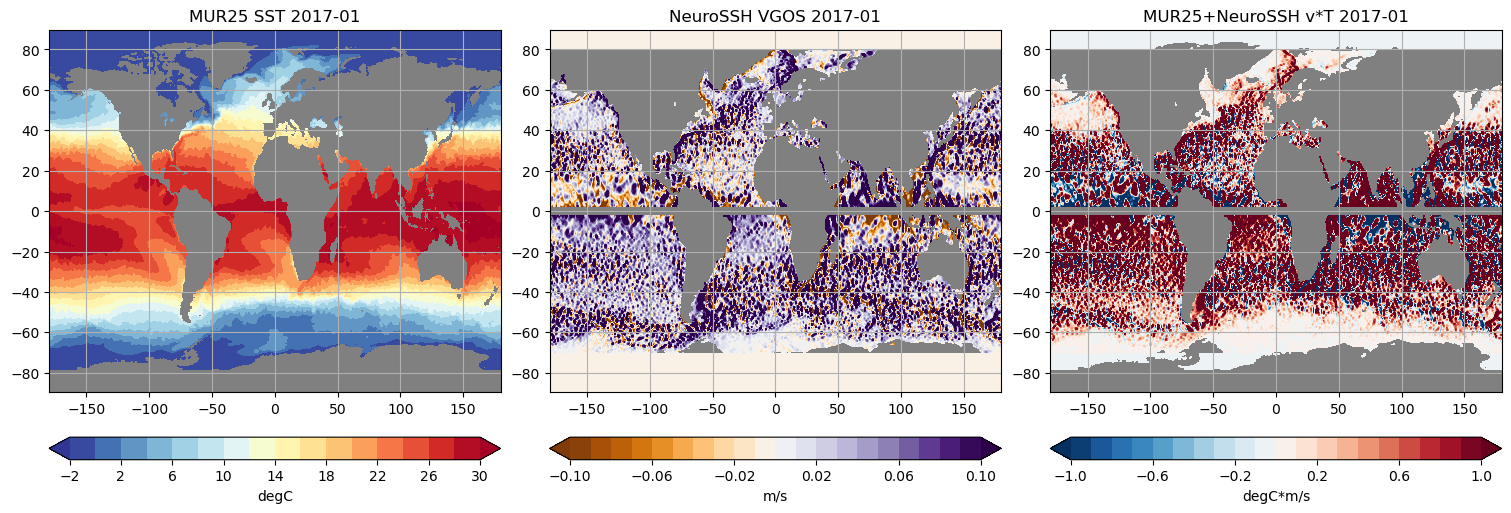

In [76]:
fig,axs = plt.subplots(1,3,figsize=(15,5),layout='constrained')

ax = axs[0] ; ax.set_title('MUR25 SST 2017-01')
dat = sst_mur25_5deg.mean('time')
cmap = 'RdYlBu_r' ; levels = np.arange(-2,31,2)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::2],orientation='horizontal',label='degC')

ax = axs[1] ; ax.set_title('NeuroSSH VGOS 2017-01')
dat = vgos_neuro_5deg.mean('time')
cmap = 'PuOr' ; levels = np.linspace(-0.1,0.1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='m/s')

ax = axs[2] ; ax.set_title('MUR25+NeuroSSH v*T 2017-01')
dat = (sst_mur25_5deg*vgos_neuro_5deg).mean('time')
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

for ax in axs:
    ax.grid()
    ax.set_facecolor('gray')
    

/srv/conda/envs/notebook/lib/python3.12/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)


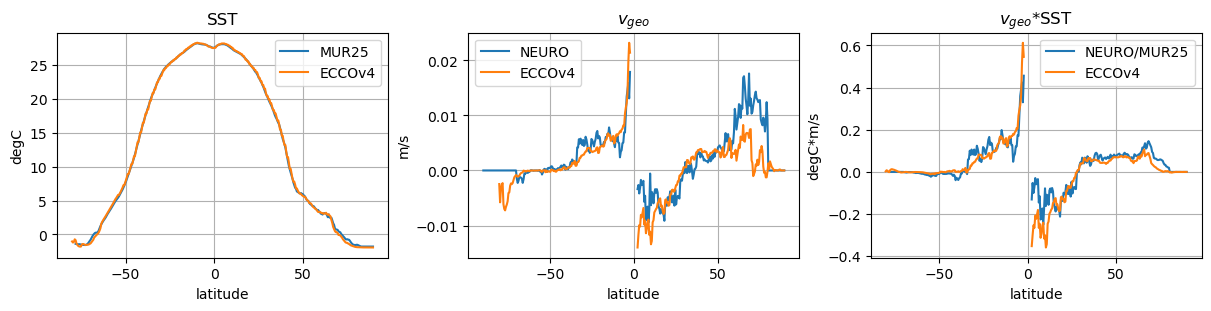

In [98]:
fig,axs = plt.subplots(1,3,figsize=(12,3),layout='constrained')

ax = axs[0] ; ax.set_title('SST')
dat = sst_mur25_5deg.mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C0',label='MUR25')
dat = sst_ecco4_ds.mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C1',label='ECCOv4')
ax.set_ylabel('degC')

ax = axs[1] ; ax.set_title('$v_{geo}$')
dat = vgos_neuro_5deg.mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C0',label='NEURO')
dat = vgos_ecco4_5deg.mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C1',label='ECCOv4')
ax.set_ylabel('m/s')

ax = axs[2] ; ax.set_title('$v_{geo}$*SST')
dat = (sst_mur25_5deg*vgos_neuro_5deg).mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C0',label='NEURO/MUR25')
dat = (sst_ecco4_ds*vgos_ecco5_5deg).mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C1',label='ECCOv4')
ax.set_ylabel('degC*m/s')

for ax in axs:
    ax.grid()
    ax.legend()
    ax.set_xlabel('latitude')

In [72]:
# NeuroSSH dataset too noisy, lets try smoothing it before remapping.

In [82]:
import numpy as np
from scipy.ndimage import gaussian_filter

def xr_gaussian_smooth(da, sigma=10):
    """
    Smoothes an xarray.DataArray with NaN handling and coordinate preservation.
    """
    def _smooth_func(arr, sigma_val):
        # 1. Separate data and mask
        mask = np.isfinite(arr).astype(float)
        filled = np.nan_to_num(arr, nan=0.0)
        
        # 2. Smooth both (mode='wrap' for longitude)
        s_data = gaussian_filter(filled, sigma=sigma_val, mode='wrap')
        s_mask = gaussian_filter(mask, sigma=sigma_val, mode='wrap')
        
        # 3. Normalize and re-mask
        # Small epsilon prevents division by zero in pure land regions
        return np.where(mask > 0, s_data / np.maximum(s_mask, 1e-10), np.nan)

    # Apply via ufunc to keep xarray metadata
    smoothed = xr.apply_ufunc(
        _smooth_func,
        da,
        kwargs={'sigma_val': sigma},
        dask='parallelized',
        output_dtypes=[da.dtype]
    )
    
    return smoothed

In [83]:
ssh_neuro_smooth = xr_gaussian_smooth(ssh_neuro_ds.adt)
ssh_neuro_smooth_5deg = ssh_neuro_regridder(ssh_neuro_smooth.rename({'lat':'y','lon':'x'}))

In [84]:
ssh_neuro_smooth_5deg = ssh_neuro_smooth_5deg.compute()

In [85]:
vgos_neuro_smooth_5deg = (g/coriolis)*gf.xr_first_derivative(ssh_neuro_smooth_5deg,dx_ecco4_5deg,dim='lon')
vgos_neuro_smooth_5deg = vgos_neuro_smooth_5deg.where(abs(vgos_neuro_smooth_5deg.lat) > 2)

/srv/conda/envs/notebook/lib/python3.12/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)


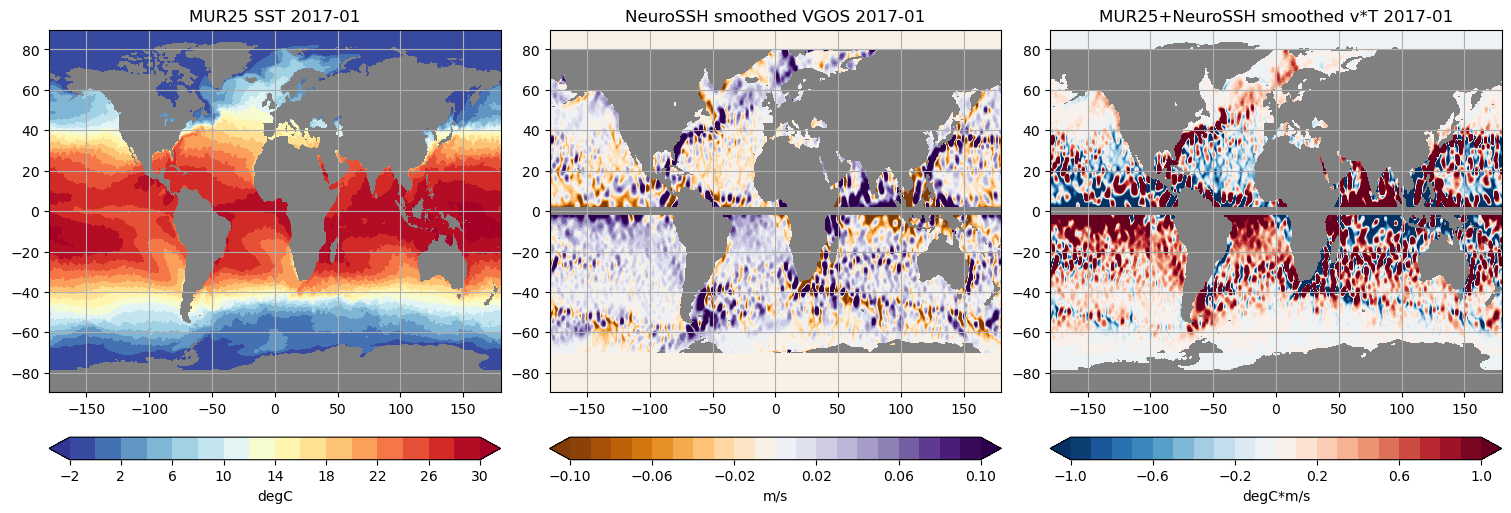

In [87]:
fig,axs = plt.subplots(1,3,figsize=(15,5),layout='constrained')

ax = axs[0] ; ax.set_title('MUR25 SST 2017-01')
dat = sst_mur25_5deg.mean('time')
cmap = 'RdYlBu_r' ; levels = np.arange(-2,31,2)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::2],orientation='horizontal',label='degC')

ax = axs[1] ; ax.set_title('NeuroSSH smoothed VGOS 2017-01')
dat = vgos_neuro_smooth_5deg.mean('time')
cmap = 'PuOr' ; levels = np.linspace(-0.1,0.1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='m/s')

ax = axs[2] ; ax.set_title('MUR25+NeuroSSH smoothed v*T 2017-01')
dat = (sst_mur25_5deg*vgos_neuro_smooth_5deg).mean('time')
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

for ax in axs:
    ax.grid()
    ax.set_facecolor('gray')
    

/srv/conda/envs/notebook/lib/python3.12/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)


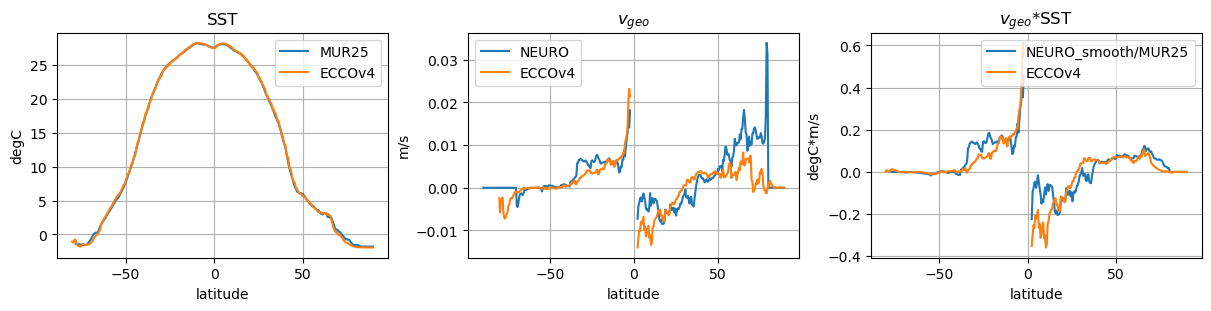

In [99]:
fig,axs = plt.subplots(1,3,figsize=(12,3),layout='constrained')

ax = axs[0] ; ax.set_title('SST')
dat = sst_mur25_5deg.mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C0',label='MUR25')
dat = sst_ecco4_ds.mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C1',label='ECCOv4')
ax.set_ylabel('degC')

ax = axs[1] ; ax.set_title('$v_{geo}$')
dat = vgos_neuro_smooth_5deg.mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C0',label='NEURO')
dat = vgos_ecco4_5deg.mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C1',label='ECCOv4')
ax.set_ylabel('m/s')

ax = axs[2] ; ax.set_title('$v_{geo}$*SST')
dat = (sst_mur25_5deg*vgos_neuro_smooth_5deg).mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C0',label='NEURO_smooth/MUR25')
dat = (sst_ecco4_ds*vgos_ecco5_5deg).mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C1',label='ECCOv4')
ax.set_ylabel('degC*m/s')

for ax in axs:
    ax.grid()
    ax.legend()
    ax.set_xlabel('latitude')

# Comparison

/srv/conda/envs/notebook/lib/python3.12/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/srv/conda/envs/notebook/lib/python3.12/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)


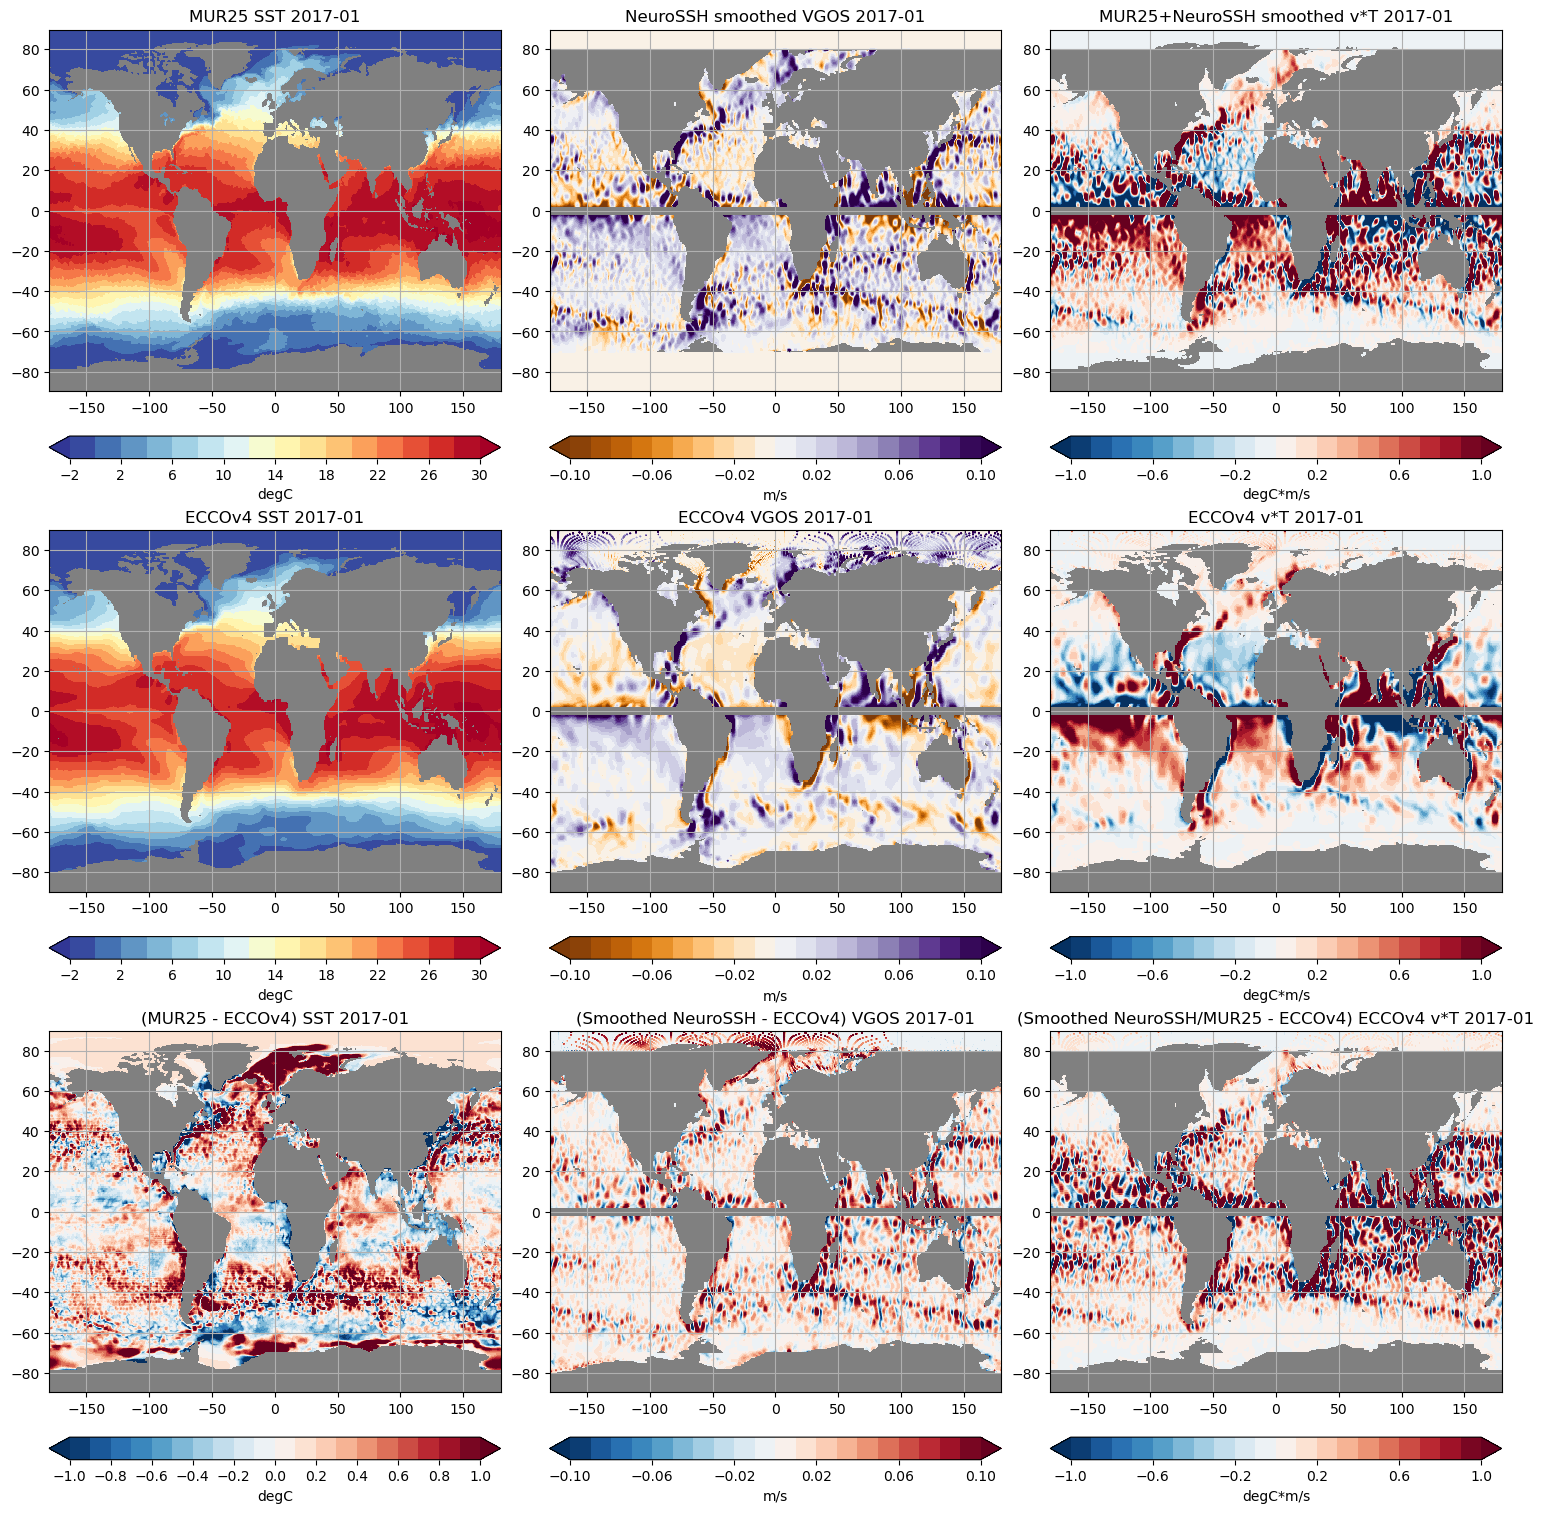

In [90]:
fig,axs = plt.subplots(3,3,figsize=(15,15),layout='constrained')

ax = axs[0,0] ; ax.set_title('MUR25 SST 2017-01')
dat = sst_mur25_5deg.mean('time')
cmap = 'RdYlBu_r' ; levels = np.arange(-2,31,2)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::2],orientation='horizontal',label='degC')

ax = axs[0,1] ; ax.set_title('NeuroSSH smoothed VGOS 2017-01')
dat = vgos_neuro_smooth_5deg.mean('time')
cmap = 'PuOr' ; levels = np.linspace(-0.1,0.1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='m/s')

ax = axs[0,2] ; ax.set_title('MUR25+NeuroSSH smoothed v*T 2017-01')
dat = (sst_mur25_5deg*vgos_neuro_smooth_5deg).mean('time')
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[1,0] ; ax.set_title('ECCOv4 SST 2017-01')
dat = sst_ecco4_ds.mean('time')
cmap = 'RdYlBu_r' ; levels = np.arange(-2,31,2)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::2],orientation='horizontal',label='degC')

ax = axs[1,1] ; ax.set_title('ECCOv4 VGOS 2017-01')
dat = vgos_ecco5_5deg.mean('time')
cmap = 'PuOr' ; levels = np.linspace(-0.1,0.1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='m/s')

ax = axs[1,2] ; ax.set_title('ECCOv4 v*T 2017-01')
dat = (sst_ecco4_ds*vgos_ecco5_5deg).mean('time')
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[2,0] ; ax.set_title('(MUR25 - ECCOv4) SST 2017-01')
dat = sst_mur25_5deg.mean('time') - sst_ecco4_ds.mean('time')
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::2],orientation='horizontal',label='degC')

ax = axs[2,1] ; ax.set_title('(Smoothed NeuroSSH - ECCOv4) VGOS 2017-01')
dat = vgos_neuro_smooth_5deg.mean('time') - vgos_ecco5_5deg.mean('time')
cmap = 'RdBu_r' ; levels = np.linspace(-0.1,0.1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='m/s')

ax = axs[2,2] ; ax.set_title('(Smoothed NeuroSSH/MUR25 - ECCOv4) ECCOv4 v*T 2017-01')
dat = (sst_mur25_5deg*vgos_neuro_smooth_5deg).mean('time') - (sst_ecco4_ds*vgos_ecco5_5deg).mean('time')
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

for ax in axs.flat:
    ax.grid()
    ax.set_facecolor('gray')
    